In [1]:
from torch.distributions import Poisson, Normal, MultivariateNormal
from gpzoo.gp import SVGP, MGGP_SVGP, VNNGP, MGGP_WSVGP, MGGP_VNNGP
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF, batched_separate_MGGP_Matern32, batched_MGGP_Matern32
from gpzoo.utilities import build_sparse_from_Kzx_knnidx, symmetrize_by_copy, add_jitter, init_Lu
import torch
import matplotlib.pyplot as plt

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
torch.manual_seed(0)

In [3]:
N = 50

In [4]:
X1 = torch.linspace(-20,20, N)[:, None]
groupsX1 = torch.zeros_like(X1.squeeze()).type(torch.long)
X2 = X1
groupsX2 = torch.ones_like(X2.squeeze()).type(torch.long)
X = torch.cat((X1, X2))
groupsX = torch.cat((groupsX1, groupsX2)).squeeze().type(torch.long)

In [5]:
n_groups = 2


group_diff_params = [1e-3, 1e-1, 0.5, 1.0]

Ws_separate = []

for group_diff_param in group_diff_params:

    M = 2*N
    
    Z = X
    groupsZ = groupsX
    
    kernel = batched_separate_MGGP_Matern32(sigma=2.0, lengthscale=5.0, group_diff_param=group_diff_param, n_groups=2)
    
    Kxx = kernel(X=X, groupsX=groupsX, Z=X, groupsZ=groupsX)
    Ws_separate.append(torch.linalg.cholesky(Kxx))

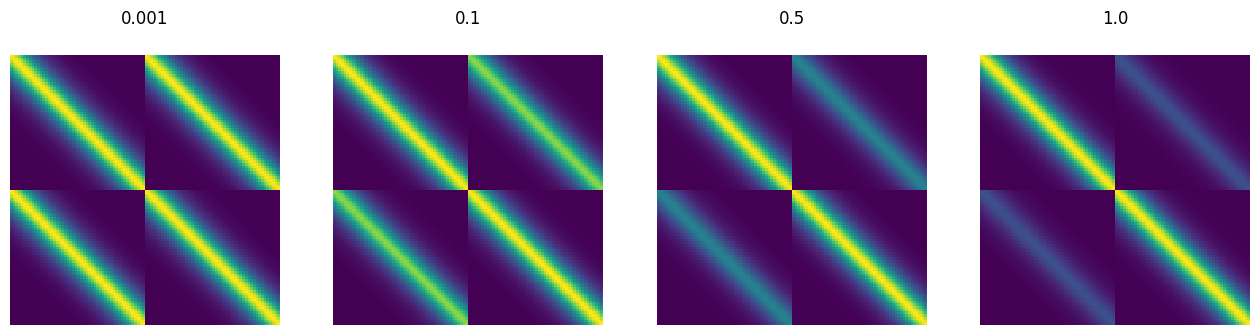

In [6]:
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow((Ws_separate[i]@Ws_separate[i].T).detach(), vmin=0, vmax=4.0)
    ax.set_axis_off()
    ax.set_title(group_diff_params[i])


In [7]:
n_groups = 2


group_diff_params = [1e-3, 1e-1, 0.5, 1.0]

Ws_non_separate = []

for group_diff_param in group_diff_params:

    M = 2*N
    
    Z = X
    groupsZ = groupsX
    
    kernel = batched_MGGP_Matern32(sigma=2.0, lengthscale=5.0, group_diff_param=group_diff_param, n_groups=2)
    
    Kxx = kernel(X=X, groupsX=groupsX, Z=X, groupsZ=groupsX)
    Ws_non_separate.append(torch.linalg.cholesky(Kxx))

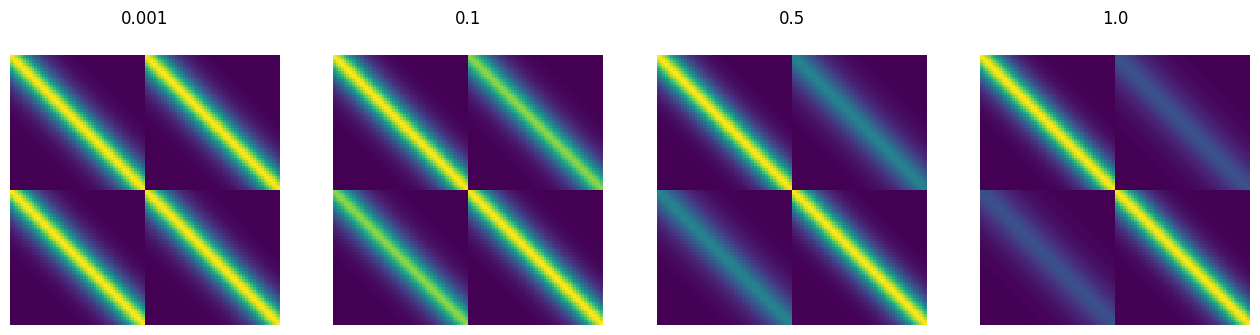

In [8]:
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow((Ws_non_separate[i]@Ws_non_separate[i].T).detach(), vmin=0, vmax=4.0)
    ax.set_axis_off()
    ax.set_title(group_diff_params[i])


In [9]:
torch.manual_seed(26)
random_vectors = torch.randn(2*N)

In [10]:
separate_samples = [(W@random_vectors).detach() for W in Ws_separate]
non_separate_samples = [(W@random_vectors).detach() for W in Ws_non_separate]

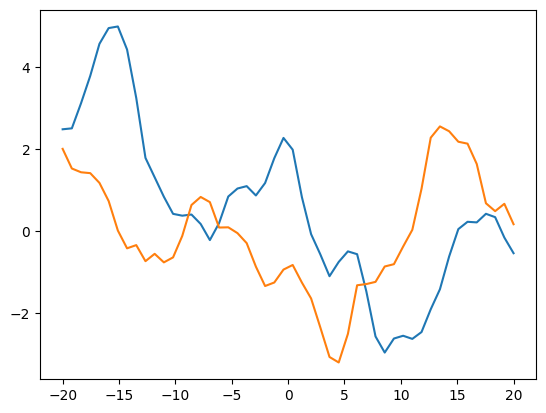

In [13]:
plt.plot(X1, separate_samples[3][:N])
plt.plot(X2, separate_samples[3][N:])

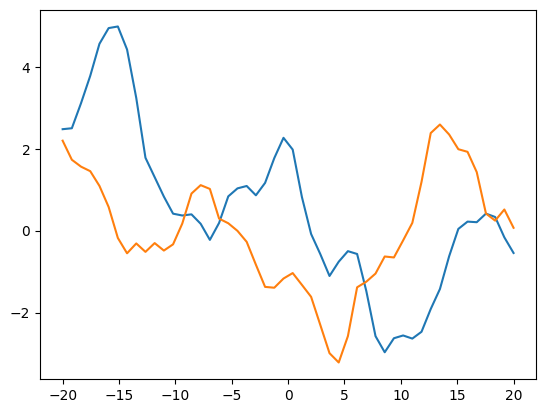

In [14]:
plt.plot(X1, non_separate_samples[3][:N])
plt.plot(X2, non_separate_samples[3][N:])